In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import timedelta
from netCDF4 import Dataset, date2num, num2date
import cftime
import glob
import os
import csv
%matplotlib inline
import datetime
import matplotlib.dates as mdates
import matplotlib.dates as md
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

files_swats = sorted(glob.glob('/Users/dave121504/ARM Project/SWATS Files/sgpswats*.nc'))
swats = xr.open_mfdataset(files_swats, combine='by_coords')

files_stamp = sorted(glob.glob('/Users/dave121504/ARM Project/STAMP Files/sgpstamp*.nc'))
stamp = xr.open_mfdataset(files_stamp, combine='by_coords')

In [7]:
swats

<xarray.Dataset> Size: 7MB
Dimensions:           (time: 11877, depth: 5)
Coordinates:
  * time              (time) datetime64[ns] 95kB 2016-02-22T00:07:00 ... 2017...
  * depth             (depth) int32 20B 5 15 25 35 60
Data variables: (12/33)
    base_time         (time) datetime64[ns] 95kB 2016-02-22 ... 2017-07-02
    time_offset       (time) datetime64[ns] 95kB dask.array<chunksize=(24,), meta=np.ndarray>
    tref              (time) float32 48kB dask.array<chunksize=(24,), meta=np.ndarray>
    qc_tref           (time) int32 48kB dask.array<chunksize=(24,), meta=np.ndarray>
    tsoil_w           (time, depth) float32 238kB dask.array<chunksize=(24, 5), meta=np.ndarray>
    qc_tsoil_w        (time, depth) int32 238kB dask.array<chunksize=(24, 5), meta=np.ndarray>
    ...                ...
    qc_watcont_e      (time, depth) int32 238kB dask.array<chunksize=(24, 5), meta=np.ndarray>
    serial_numbers_w  (time, depth) float64 475kB dask.array<chunksize=(24, 5), meta=np.ndarray>
    serial_numbers_e  (time, depth) float64 475kB dask.array<chunksize=(24, 5), meta=np.ndarray>
    lat               (time) float32 48kB 36.6 36.6 36.6 36.6 ... 36.6 36.6 36.6
    lon               (time) float32 48kB -97.49 -97.49 -97.49 ... -97.49 -97.49
    alt               (time) float32 48kB 318.0 318.0 318.0 ... 318.0 318.0
Attributes: (12/33)
    command_line:            swats_ingest -s sgp -f E13
    Conventions:             ARM-1.0
    process_version:         ingest-swats-12.0-0.el6
    dod_version:             swats-b1-2.3
    input_source:            /data/collection/sgp/sgpswatsE13.00/1456099620.icm
    site_id:                 sgp
    ...                      ...
    qc_bit_3_assessment:     Bad
    qc_bit_4_description:    Difference between current and previous values e...
    qc_bit_4_assessment:     Indeterminate
    qc_bit_5_description:    One or more input values to an equation are inva...
    qc_bit_5_assessment:     Bad
    history:                 created by user dsmgr on machine ruby at 2016-02...

In [8]:
stamp

<xarray.Dataset> Size: 22MB
Dimensions:                                  (time: 23764, depth: 6)
Coordinates:
  * time                                     (time) datetime64[ns] 190kB 2016...
  * depth                                    (depth) int32 24B 5 10 20 50 75 100
Data variables: (12/49)
    base_time                                (time) datetime64[ns] 190kB 2016...
    time_offset                              (time) datetime64[ns] 190kB dask.array<chunksize=(16,), meta=np.ndarray>
    soil_specific_water_content_west         (time, depth) float32 570kB dask.array<chunksize=(16, 6), meta=np.ndarray>
    qc_soil_specific_water_content_west      (time, depth) int32 570kB dask.array<chunksize=(16, 6), meta=np.ndarray>
    plant_water_availability_west            (time, depth) float32 570kB dask.array<chunksize=(16, 6), meta=np.ndarray>
    qc_plant_water_availability_west         (time, depth) int32 570kB dask.array<chunksize=(16, 6), meta=np.ndarray>
    ...                                       ...
    qc_real_dielectric_permittivity_east     (time, depth) int32 570kB dask.array<chunksize=(16, 6), meta=np.ndarray>
    battery_voltage                          (time) float32 95kB dask.array<chunksize=(16,), meta=np.ndarray>
    qc_battery_voltage                       (time) int32 95kB dask.array<chunksize=(16,), meta=np.ndarray>
    lat                                      (time) float32 95kB 36.6 ... 36.6
    lon                                      (time) float32 95kB -97.49 ... -...
    alt                                      (time) float32 95kB 318.0 ... 318.0
Attributes: (12/20)
    command_line:          stamp_ingest -s sgp -f E13 -D
    Conventions:           ARM-1.1
    process_version:       ingest-stamp-1.0-0.el6
    dod_version:           stamp-b1-1.0
    input_source:          /data/collection/sgp/sgpstampE13.00/Table30.201602...
    site_id:               sgp
    ...                    ...
    qc_bit_1_assessment:   Bad
    qc_bit_2_description:  Value is less than the valid_min.
    qc_bit_2_assessment:   Bad
    qc_bit_3_description:  Value is greater than the valid_max.
    qc_bit_3_assessment:   Bad
    history:               created by user dsmgr on machine ruby at 2016-03-2...

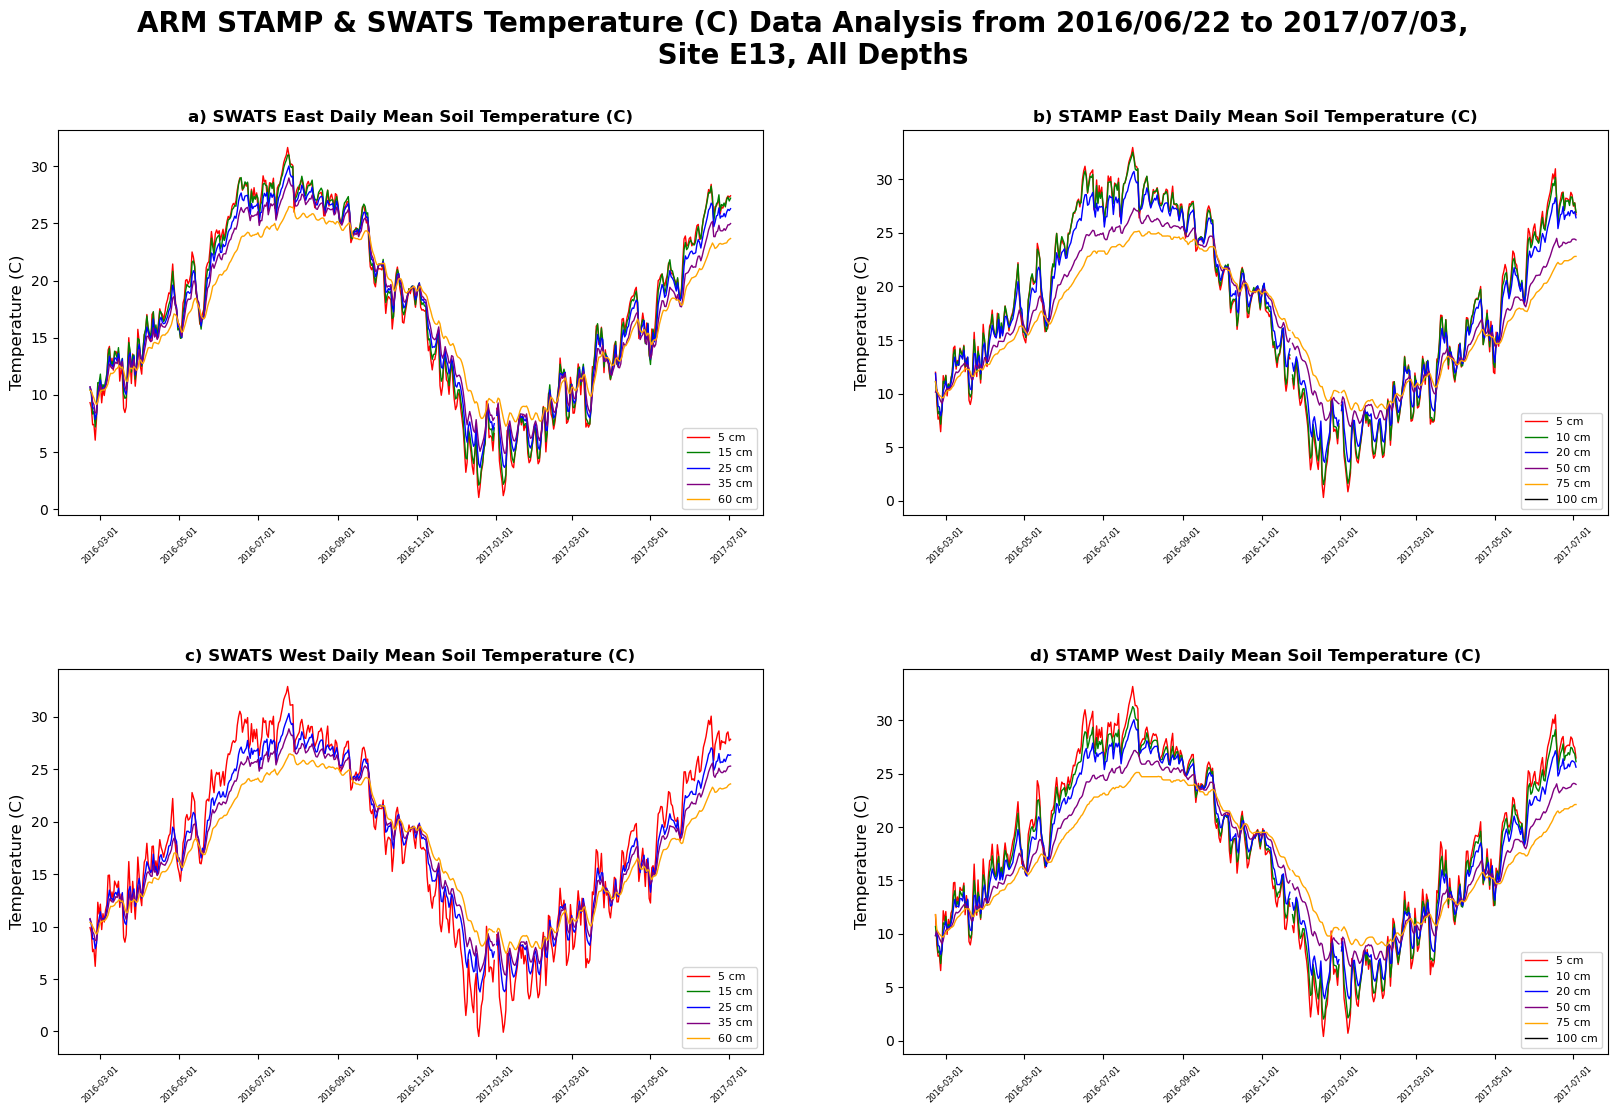

In [9]:
fig, axes = plt.subplots(2, 2, figsize = (20, 12))

time_swats = swats['time']
time_stamp = stamp['time']

######   EAST  ######
#5cm, STARTING WITH SWATS (plot A)
swats_tempE_5 = swats['tsoil_e'].isel(depth=0)
swats_daily_temp_E_5 = swats_tempE_5.resample(time='1D').mean()

#15cm
swats_tempE_15 = swats['tsoil_e'].isel(depth=1)
swats_daily_temp_E_15 = swats_tempE_15.resample(time='1D').mean()

#25cm
swats_tempE_25 = swats['tsoil_e'].isel(depth=2)
swats_daily_temp_E_25 = swats_tempE_25.resample(time='1D').mean()


#35cm
swats_tempE_35 = swats['tsoil_e'].isel(depth=3)
swats_daily_temp_E_35 = swats_tempE_35.resample(time='1D').mean()

#60cm
swats_tempE_60 = swats['tsoil_e'].isel(depth=4)
swats_daily_temp_E_60 = swats_tempE_60.resample(time='1D').mean()

#swats temps plot (a)
axes[0,0].plot(swats_daily_temp_E_5['time'], swats_daily_temp_E_5, color = 'red', linewidth = 1, label = '5 cm')
axes[0,0].plot(swats_daily_temp_E_15['time'], swats_daily_temp_E_15, color = 'green', linewidth = 1, label = '15 cm')
axes[0,0].plot(swats_daily_temp_E_25['time'], swats_daily_temp_E_25, color = 'blue', linewidth = 1, label = '25 cm')
axes[0,0].plot(swats_daily_temp_E_35['time'], swats_daily_temp_E_35, color = 'purple', linewidth = 1, label = '35 cm')
axes[0,0].plot(swats_daily_temp_E_60['time'], swats_daily_temp_E_60, color = 'orange', linewidth = 1, label = '60 cm')
axes[0,0].set_ylabel('Temperature (C)', fontsize = 12)
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0,0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[0,0].set_title("a) SWATS East Daily Mean Soil Temperature (C)", fontweight = 'bold', fontsize = 12)
axes[0,0].legend(loc = "lower right", fontsize = 8)


###  STAMP ###
#5cm, 10, 20, 50, 75, 100

#5cm
stamp_tempE_5 = stamp['soil_temperature_east'].isel(depth=0)
stamp_daily_tempE_5 = stamp_tempE_5.resample(time='1D').mean()

#10cm
stamp_tempE_10 = stamp['soil_temperature_east'].isel(depth=1)
stamp_daily_tempE_10 = stamp_tempE_10.resample(time='1D').mean()

#20cm
stamp_tempE_20 = stamp['soil_temperature_east'].isel(depth=2)
stamp_daily_tempE_20 = stamp_tempE_20.resample(time='1D').mean()

#50cm 
stamp_tempE_50 = stamp['soil_temperature_east'].isel(depth=3)
stamp_daily_tempE_50 = stamp_tempE_50.resample(time='1D').mean()

#75cm
stamp_tempE_75 = stamp['soil_temperature_east'].isel(depth=4)
stamp_daily_tempE_75 = stamp_tempE_75.resample(time='1D').mean()

#100cm
stamp_tempE_100 = stamp['soil_temperature_east'].isel(depth=5)
stamp_daily_tempE_100 = stamp_tempE_100.resample(time='1D').mean()

#stamp temps plot b
axes[0,1].plot(stamp_daily_tempE_5['time'], stamp_daily_tempE_5, color = 'red', linewidth = 1, label = '5 cm')
axes[0,1].plot(stamp_daily_tempE_10['time'], stamp_daily_tempE_10, color = 'green', linewidth = 1, label = '10 cm')
axes[0,1].plot(stamp_daily_tempE_20['time'], stamp_daily_tempE_20, color = 'blue', linewidth = 1, label = '20 cm')
axes[0,1].plot(stamp_daily_tempE_50['time'], stamp_daily_tempE_50, color = 'purple', linewidth = 1, label = '50 cm')
axes[0,1].plot(stamp_daily_tempE_75['time'], stamp_daily_tempE_75, color = 'orange', linewidth = 1, label = '75 cm')
axes[0,1].plot(stamp_daily_tempE_100['time'], stamp_daily_tempE_100, color = 'black', linewidth = 1, label = '100 cm')
axes[0,1].set_ylabel('Temperature (C)', fontsize = 12)
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0,1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[0,1].set_title("b) STAMP East Daily Mean Soil Temperature (C)", fontweight = 'bold', fontsize = 12)
axes[0,1].legend(loc = "lower right", fontsize = 8)


##### WEST #####
#5cm, STARTING WITH SWATS (plot C)
swats_tempW_5 = swats['tsoil_w'].isel(depth=0)
swats_daily_temp_W_5 = swats_tempW_5.resample(time='1D').mean()

#15cm
swats_tempW_15 = swats['tsoil_w'].isel(depth=1)
swats_daily_temp_W_15 = swats_tempW_15.resample(time='1D').mean()

#25cm
swats_tempW_25 = swats['tsoil_w'].isel(depth=2)
swats_daily_temp_W_25 = swats_tempW_25.resample(time='1D').mean()


#35cm
swats_tempW_35 = swats['tsoil_w'].isel(depth=3)
swats_daily_temp_W_35 = swats_tempW_35.resample(time='1D').mean()

#60cm
swats_tempW_60 = swats['tsoil_w'].isel(depth=4)
swats_daily_temp_W_60 = swats_tempW_60.resample(time='1D').mean()

#swats temps plot (c)
axes[1,0].plot(swats_daily_temp_W_5['time'], swats_daily_temp_W_5, color = 'red', linewidth = 1, label = '5 cm')
axes[1,0].plot(swats_daily_temp_W_15['time'], swats_daily_temp_W_15, color = 'green', linewidth = 1, label = '15 cm')
axes[1,0].plot(swats_daily_temp_W_25['time'], swats_daily_temp_W_25, color = 'blue', linewidth = 1, label = '25 cm')
axes[1,0].plot(swats_daily_temp_W_35['time'], swats_daily_temp_W_35, color = 'purple', linewidth = 1, label = '35 cm')
axes[1,0].plot(swats_daily_temp_W_60['time'], swats_daily_temp_W_60, color = 'orange', linewidth = 1, label = '60 cm')
axes[1,0].set_ylabel('Temperature (C)', fontsize = 12)
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[1,0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[1,0].set_title("c) SWATS West Daily Mean Soil Temperature (C)", fontweight = 'bold', fontsize = 12)
axes[1,0].legend(loc = "lower right", fontsize = 8)

###  STAMP ###
#5cm
stamp_tempW_5 = stamp['soil_temperature_west'].isel(depth=0)
stamp_daily_tempW_5 = stamp_tempW_5.resample(time='1D').mean()

#10cm
stamp_tempW_10 = stamp['soil_temperature_west'].isel(depth=1)
stamp_daily_tempW_10 = stamp_tempW_10.resample(time='1D').mean()

#20cm
stamp_tempW_20 = stamp['soil_temperature_west'].isel(depth=2)
stamp_daily_tempW_20 = stamp_tempW_20.resample(time='1D').mean()

#50cm 
stamp_tempW_50 = stamp['soil_temperature_west'].isel(depth=3)
stamp_daily_tempW_50 = stamp_tempW_50.resample(time='1D').mean()

#75cm
stamp_tempW_75 = stamp['soil_temperature_west'].isel(depth=4)
stamp_daily_tempW_75 = stamp_tempW_75.resample(time='1D').mean()

#100cm
stamp_tempW_100 = stamp['soil_temperature_west'].isel(depth=5)
stamp_daily_tempW_100 = stamp_tempW_100.resample(time='1D').mean()

#stamp temps plot d
axes[1,1].plot(stamp_daily_tempW_5['time'], stamp_daily_tempW_5, color = 'red', linewidth = 1, label = '5 cm')
axes[1,1].plot(stamp_daily_tempW_10['time'], stamp_daily_tempW_10, color = 'green', linewidth = 1, label = '10 cm')
axes[1,1].plot(stamp_daily_tempW_20['time'], stamp_daily_tempW_20, color = 'blue', linewidth = 1, label = '20 cm')
axes[1,1].plot(stamp_daily_tempW_50['time'], stamp_daily_tempW_50, color = 'purple', linewidth = 1, label = '50 cm')
axes[1,1].plot(stamp_daily_tempW_75['time'], stamp_daily_tempW_75, color = 'orange', linewidth = 1, label = '75 cm')
axes[1,1].plot(stamp_daily_tempW_100['time'], stamp_daily_tempW_100, color = 'black', linewidth = 1, label = '100 cm')
axes[1,1].set_ylabel('Temperature (C)', fontsize = 12)
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[1,1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[1,1].set_title("d) STAMP West Daily Mean Soil Temperature (C)", fontweight = 'bold', fontsize = 12)
axes[1,1].legend(loc = "lower right", fontsize = 8)





fig.suptitle(f"ARM STAMP & SWATS Temperature (C) Data Analysis from 2016/06/22 to 2017/07/03, \n Site E13, All Depths", fontweight = 'bold', fontsize = 20)           
plt.subplots_adjust(hspace=0.4, wspace = 0.2)
plt.savefig('ARM_temp_analysis_all_depths.png', dpi=300, bbox_inches='tight')

In [10]:
os.getcwd()

'/Users/dave121504/ARM Project'